# Beauty Influencer Engagement Analysis
## A Data-Driven Playbook: How to Grow from Micro to Macro

**Research Questions:**
1. Do caption features explain variation in post-level engagement rate?
2. Do image features significantly associate with engagement rate?
3. Does the content–engagement relationship differ across micro, mid-level, and macro influencer tiers?

**Story Frame:** This notebook translates regression outputs into actionable advice — what should a beauty influencer *actually do differently* to improve engagement and grow their audience tier.

In [2]:
# ── Cell 1: Import Libraries & Load Data ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Colour palette (consistent across all figures) ──
TIER_COLORS = {'micro': '#4C72B0', 'mid': '#DD8452', 'macro': '#55A868'}
CAPTION_COLOR = '#4C72B0'
IMAGE_COLOR  = '#DD8452'
HIGHLIGHT    = '#E74C3C'

# Load data
caption_df = pd.read_csv('/content/beauty_posts_caption.csv')
image_df   = pd.read_csv('/content/beauty_posts_image.csv')

print('Caption CSV shape:', caption_df.shape)
print('Image CSV shape:  ', image_df.shape)
print('Tiers in caption data:', caption_df['tier'].value_counts().to_dict())

Caption CSV shape: (9821, 18)
Image CSV shape:   (9821, 23)
Tiers in caption data: {'micro': 5021, 'mid': 2921, 'macro': 1879}


In [3]:
# ── Cell 2: Merge & Clean ──
image_cols = ['post_id', 'brightness', 'colorfulness', 'face_present', 'face_count', 'edge_density']
merged_df  = pd.merge(caption_df, image_df[image_cols], on='post_id', how='inner')

features = [
    'sentiment_score', 'caption_length', 'hashtag_count',
    'emoji_count', 'has_cta',
    'brightness', 'colorfulness', 'face_present', 'edge_density'
]

print('Missing values before cleaning:')
print(merged_df[features].isnull().sum())

clean_df = merged_df.dropna(subset=features).copy()
print(f'\nRows retained: {len(clean_df):,} / {len(merged_df):,}')

# Tier order for consistent plotting
tier_order = ['micro', 'mid', 'macro']
clean_df['tier'] = pd.Categorical(clean_df['tier'], categories=tier_order, ordered=True)

Missing values before cleaning:
sentiment_score     0
caption_length      0
hashtag_count       0
emoji_count         0
has_cta             0
brightness         84
colorfulness       84
face_present       84
edge_density       84
dtype: int64

Rows retained: 9,737 / 9,821


In [4]:
# ── Cell 3: Helper — OLS with numpy (no statsmodels dependency) ──

def ols_fit(X_df, y_series):
    """Fit OLS and return dict with coefs, r2, p-values."""
    X = X_df.values.astype(float)
    y = y_series.values.astype(float)
    X_c = np.column_stack([np.ones(len(X)), X])
    coefs, _, _, _ = np.linalg.lstsq(X_c, y, rcond=None)
    y_pred = X_c @ coefs
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    n, k = X_c.shape
    mse = ss_res / (n - k)
    cov = mse * np.linalg.pinv(X_c.T @ X_c)
    se  = np.sqrt(np.diag(cov))
    t   = coefs / se
    pv  = 2 * stats.t.sf(np.abs(t), df=n - k)
    names = ['const'] + list(X_df.columns)
    return {'r2': r2, 'coef': dict(zip(names, coefs)),
            'pval': dict(zip(names, pv)), 'se': dict(zip(names, se))}

caption_features = ['sentiment_score', 'caption_length', 'hashtag_count', 'emoji_count', 'has_cta']
image_features   = ['brightness', 'colorfulness', 'face_present', 'edge_density']
all_features     = caption_features + image_features

Y = clean_df['engagement_rate']

model1 = ols_fit(clean_df[caption_features], Y)
model2 = ols_fit(clean_df[image_features], Y)
model3 = ols_fit(clean_df[all_features], Y)

print(f"Model 1 R² (Caption only): {model1['r2']:.4f}")
print(f"Model 2 R² (Image only):   {model2['r2']:.4f}")
print(f"Model 3 R² (All features): {model3['r2']:.4f}")

Model 1 R² (Caption only): 0.0044
Model 2 R² (Image only):   0.0069
Model 3 R² (All features): 0.0114


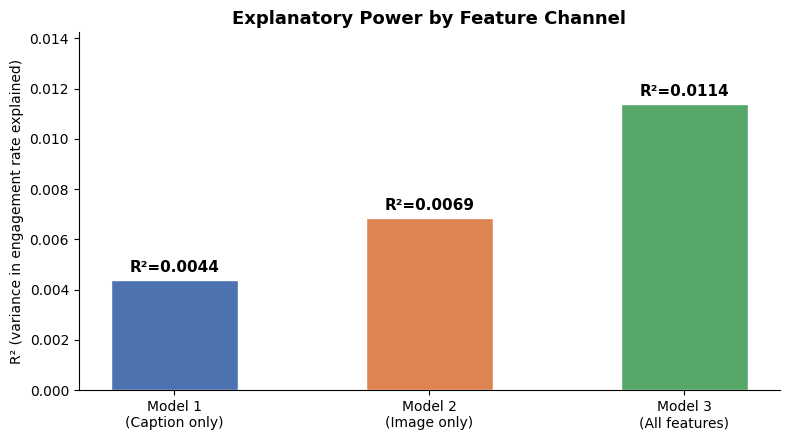

Key takeaway: Image features (R²= 0.0069 ) explain slightly more variance than caption features alone.


In [5]:
# ── Cell 4: Figure 1 — R² Comparison (Models 1–3) ──

fig, ax = plt.subplots(figsize=(8, 4.5))
names  = ['Model 1\n(Caption only)', 'Model 2\n(Image only)', 'Model 3\n(All features)']
r2vals = [model1['r2'], model2['r2'], model3['r2']]
colors = [CAPTION_COLOR, IMAGE_COLOR, '#55A868']
bars = ax.bar(names, r2vals, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, r2vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
            f'R²={val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Explanatory Power by Feature Channel', fontsize=13, fontweight='bold')
ax.set_ylabel('R² (variance in engagement rate explained)')
ax.set_ylim(0, max(r2vals) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig1_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key takeaway: Image features (R²=', round(model2["r2"],4), ') explain slightly more variance than caption features alone.')

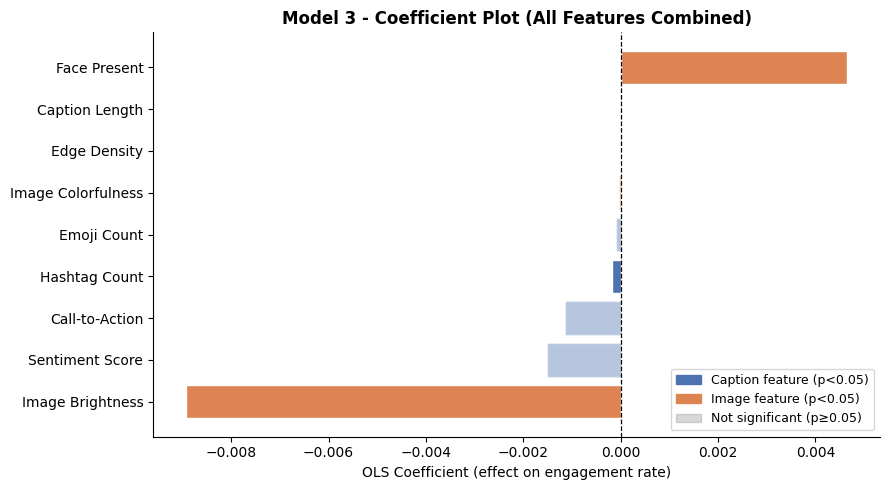

In [6]:
# ── Cell 5: Figure 2 — Model 3 Coefficient Plot (All Features) ──

coefs = {k: v for k, v in model3['coef'].items() if k != 'const'}
pvals = {k: v for k, v in model3['pval'].items() if k != 'const'}

feature_labels = {
    'sentiment_score': 'Sentiment Score',
    'caption_length':  'Caption Length',
    'hashtag_count':   'Hashtag Count',
    'emoji_count':     'Emoji Count',
    'has_cta':         'Call-to-Action',
    'brightness':      'Image Brightness',
    'colorfulness':    'Image Colorfulness',
    'face_present':    'Face Present',
    'edge_density':    'Edge Density'
}

sorted_keys = sorted(coefs.keys(), key=lambda k: coefs[k])
vals   = [coefs[k] for k in sorted_keys]
labels = [feature_labels[k] for k in sorted_keys]
cols   = [CAPTION_COLOR if k in caption_features else IMAGE_COLOR for k in sorted_keys]
alphas = [1.0 if pvals[k] < 0.05 else 0.4 for k in sorted_keys]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(labels, vals, color=cols, alpha=0.85, edgecolor='white')
for bar, a in zip(bars, alphas):
    bar.set_alpha(a)
ax.axvline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_title('Model 3 - Coefficient Plot (All Features Combined)', fontsize=12, fontweight='bold')
ax.set_xlabel('OLS Coefficient (effect on engagement rate)')
legend_handles = [
    mpatches.Patch(color=CAPTION_COLOR, label='Caption feature (p<0.05)'),
    mpatches.Patch(color=IMAGE_COLOR,   label='Image feature (p<0.05)'),
    mpatches.Patch(color='grey', alpha=0.3, label='Not significant (p≥0.05)')
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig2_model3_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

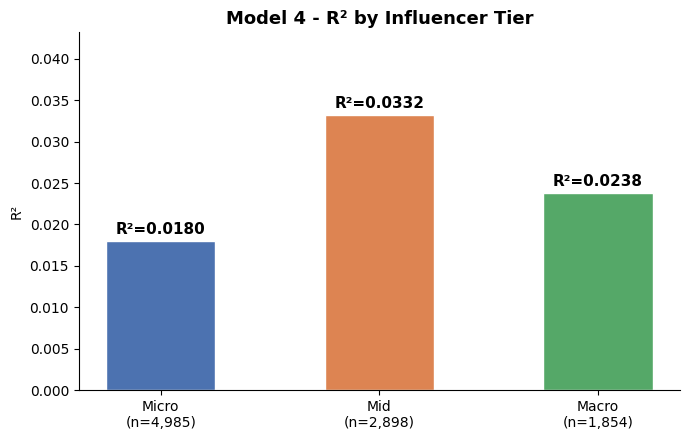

Key takeaway: Content features explain MORE variance for mid-tier influencers, suggesting content optimisation is most impactful during growth from micro to macro.


In [7]:
# ── Cell 6: Figure 3 — R² by Influencer Tier (Model 4) ──

tier_models = {}
for tier in tier_order:
    sub = clean_df[clean_df['tier'] == tier]
    tier_models[tier] = ols_fit(sub[all_features], sub['engagement_rate'])

fig, ax = plt.subplots(figsize=(7, 4.5))
tier_ns = {t: (clean_df['tier'] == t).sum() for t in tier_order}
tlabels = [f"{t.capitalize()}\n(n={tier_ns[t]:,})" for t in tier_order]
r2tiers = [tier_models[t]['r2'] for t in tier_order]
tcolors = [TIER_COLORS[t] for t in tier_order]
bars = ax.bar(tlabels, r2tiers, color=tcolors, width=0.5, edgecolor='white')
for bar, val in zip(bars, r2tiers):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f'R²={val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Model 4 - R² by Influencer Tier', fontsize=13, fontweight='bold')
ax.set_ylabel('R²')
ax.set_ylim(0, max(r2tiers) * 1.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig3_tier_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key takeaway: Content features explain MORE variance for mid-tier influencers,'
      ' suggesting content optimisation is most impactful during growth from micro to macro.')

Engagement rate statistics by tier:
         mean  median     std
tier                         
micro  0.0437  0.0310  0.0506
mid    0.0388  0.0252  0.0442
macro  0.0366  0.0266  0.0399


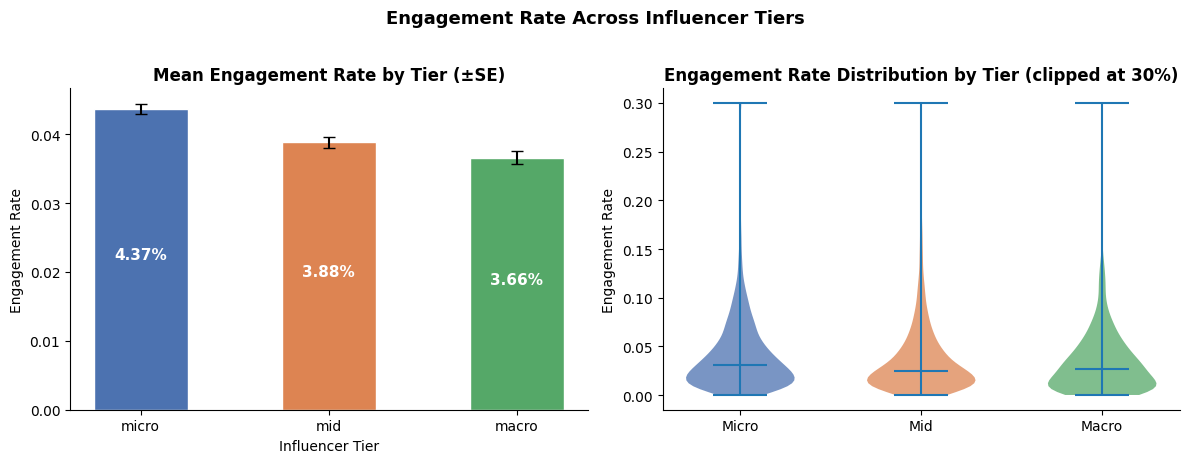

In [8]:
# ── Cell 7: Figure 4 — Mean Engagement Rate by Tier ──
# NEW: Shows the engagement rate gap between tiers — framing the 'growth challenge'

tier_stats = clean_df.groupby('tier', observed=True)['engagement_rate'].agg(['mean','median','std']).reindex(tier_order)
print('Engagement rate statistics by tier:')
print(tier_stats.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: bar chart of mean ER
ax = axes[0]
bars = ax.bar(tier_order, tier_stats['mean'], color=[TIER_COLORS[t] for t in tier_order],
              width=0.5, edgecolor='white', yerr=tier_stats['std']/np.sqrt(list(tier_ns.values())),
              capsize=4, error_kw={'linewidth': 1.5})
ax.set_title('Mean Engagement Rate by Tier (±SE)', fontweight='bold')
ax.set_ylabel('Engagement Rate')
ax.set_xlabel('Influencer Tier')
for bar, val in zip(bars, tier_stats['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
            f'{val:.2%}', ha='center', color='white', fontweight='bold', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

# Right: distribution (violin / box)
ax = axes[1]
data_by_tier = [clean_df[clean_df['tier']==t]['engagement_rate'].clip(0, 0.3) for t in tier_order]
vp = ax.violinplot(data_by_tier, positions=[1,2,3], widths=0.6, showmedians=True)
for pc, t in zip(vp['bodies'], tier_order):
    pc.set_facecolor(TIER_COLORS[t])
    pc.set_alpha(0.75)
ax.set_xticks([1,2,3])
ax.set_xticklabels([t.capitalize() for t in tier_order])
ax.set_title('Engagement Rate Distribution by Tier (clipped at 30%)', fontweight='bold')
ax.set_ylabel('Engagement Rate')
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Engagement Rate Across Influencer Tiers', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_er_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

Engagement rate by hashtag count range:
               mean  count
hashtag_bin               
0-2          0.0368   1212
3-5          0.0349   1047
6-10         0.0390   1084
11-15        0.0414    804
16-20        0.0397    635
21+          0.0425   1763


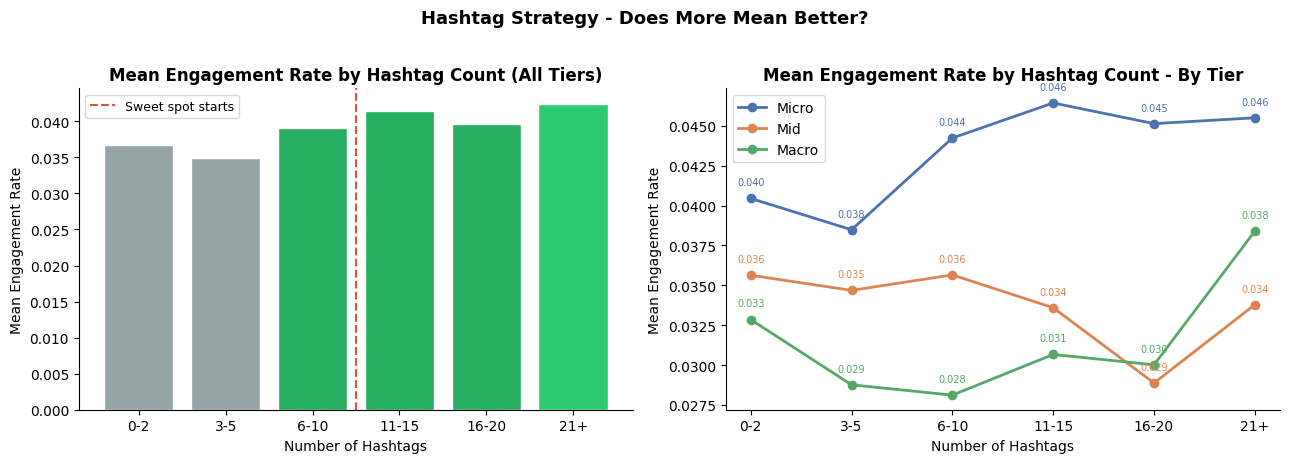

In [9]:
# ── Cell 8: Figure 5 — Hashtag Count vs Engagement Rate ──
# NEW: Optimal hashtag range analysis — actionable for content creators

bins   = [0, 2, 5, 10, 15, 20, 41]
labels = ['0-2', '3-5', '6-10', '11-15', '16-20', '21+']
clean_df['hashtag_bin'] = pd.cut(clean_df['hashtag_count'], bins=bins, labels=labels)

hash_stats = clean_df.groupby('hashtag_bin', observed=True)['engagement_rate'].agg(['mean','count'])
print('Engagement rate by hashtag count range:')
print(hash_stats.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overall
ax = axes[0]
bar_colors = ['#95a5a6']*2 + ['#27ae60']*3 + ['#2ecc71']*1
ax.bar(hash_stats.index, hash_stats['mean'], color=bar_colors, edgecolor='white')
ax.set_title('Mean Engagement Rate by Hashtag Count (All Tiers)', fontweight='bold')
ax.set_xlabel('Number of Hashtags')
ax.set_ylabel('Mean Engagement Rate')
ax.axvline(2.5, color=HIGHLIGHT, linestyle='--', linewidth=1.5, label='Sweet spot starts')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Right: by tier
ax = axes[1]
for tier in tier_order:
    sub = clean_df[clean_df['tier']==tier]
    ts  = sub.groupby('hashtag_bin', observed=True)['engagement_rate'].mean()
    ax.plot(ts.index, ts.values, marker='o', label=tier.capitalize(),
            color=TIER_COLORS[tier], linewidth=2)

    # 为每个点添加数值标注
    for x, y in zip(ts.index, ts.values):
        ax.annotate(f'{y:.3f}',
                    xy=(x, y),
                    xytext=(0, 8),           # 向上偏移8个点
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=7,
                    color=TIER_COLORS[tier])

ax.set_title('Mean Engagement Rate by Hashtag Count - By Tier', fontweight='bold')
ax.set_xlabel('Number of Hashtags')
ax.set_ylabel('Mean Engagement Rate')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Hashtag Strategy - Does More Mean Better?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_hashtag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Engagement rate by hashtag count range:
               mean  count
hashtag_bin               
0-2          0.0368   1212
3-5          0.0349   1047
6-10         0.0390   1084
11-15        0.0414    804
16-20        0.0397    635
21+          0.0425   1763


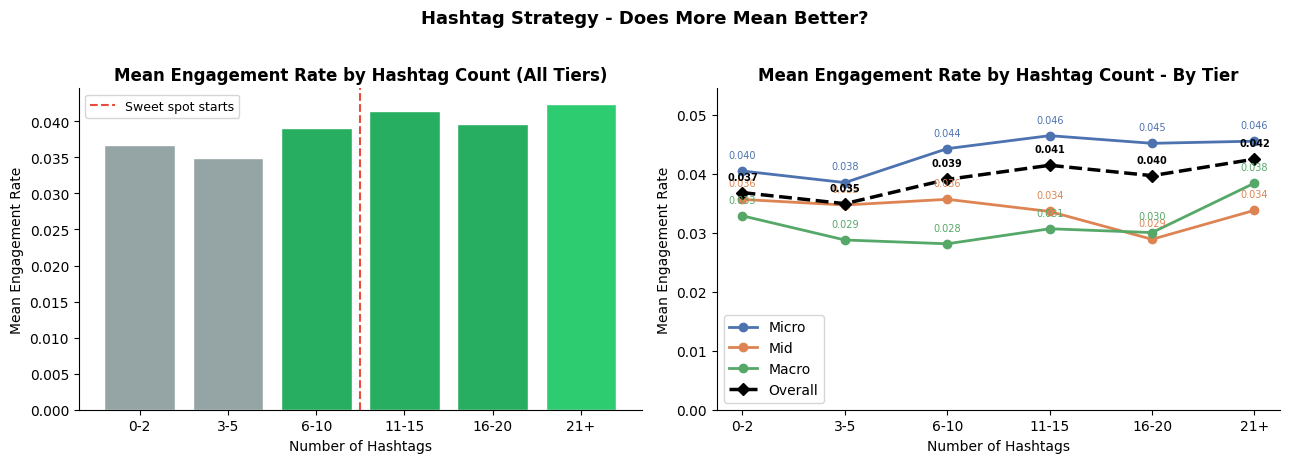

In [10]:
bins   = [0, 2, 5, 10, 15, 20, 41]
labels = ['0-2', '3-5', '6-10', '11-15', '16-20', '21+']
clean_df['hashtag_bin'] = pd.cut(clean_df['hashtag_count'], bins=bins, labels=labels)
hash_stats = clean_df.groupby('hashtag_bin', observed=True)['engagement_rate'].agg(['mean','count'])
print('Engagement rate by hashtag count range:')
print(hash_stats.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overall
ax = axes[0]
bar_colors = ['#95a5a6']*2 + ['#27ae60']*3 + ['#2ecc71']*1
ax.bar(hash_stats.index, hash_stats['mean'], color=bar_colors, edgecolor='white')
ax.set_title('Mean Engagement Rate by Hashtag Count (All Tiers)', fontweight='bold')
ax.set_xlabel('Number of Hashtags')
ax.set_ylabel('Mean Engagement Rate')
ax.axvline(2.5, color=HIGHLIGHT, linestyle='--', linewidth=1.5, label='Sweet spot starts')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Right: by tier
ax = axes[1]
for tier in tier_order:
    sub = clean_df[clean_df['tier']==tier]
    ts  = sub.groupby('hashtag_bin', observed=True)['engagement_rate'].mean()
    ax.plot(ts.index, ts.values, marker='o', label=tier.capitalize(),
            color=TIER_COLORS[tier], linewidth=2)
    for x, y in zip(ts.index, ts.values):
        ax.annotate(f'{y:.3f}',
                    xy=(x, y), xytext=(0, 8),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=7, color=TIER_COLORS[tier])

# ── Overall 线（来自左图柱状图数据）──────────────────────────────
overall_ts = hash_stats['mean']
ax.plot(overall_ts.index, overall_ts.values, marker='D', label='Overall',
        color='black', linewidth=2.5, linestyle='--')
for x, y in zip(overall_ts.index, overall_ts.values):
    ax.annotate(f'{y:.3f}',
                xy=(x, y), xytext=(0, 8),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=7, color='black', fontweight='bold')

ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 1.15)
ax.set_title('Mean Engagement Rate by Hashtag Count - By Tier', fontweight='bold')
ax.set_xlabel('Number of Hashtags')
ax.set_ylabel('Mean Engagement Rate')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Hashtag Strategy - Does More Mean Better?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_hashtag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Engagement rate by hashtag count range:
               mean  count
hashtag_bin               
0            0.0383    741
1-2          0.0341    853
3-5          0.0349    911
6-10         0.0411   1021
11-15        0.0406    780
16-20        0.0408    590
21+          0.0424   1649


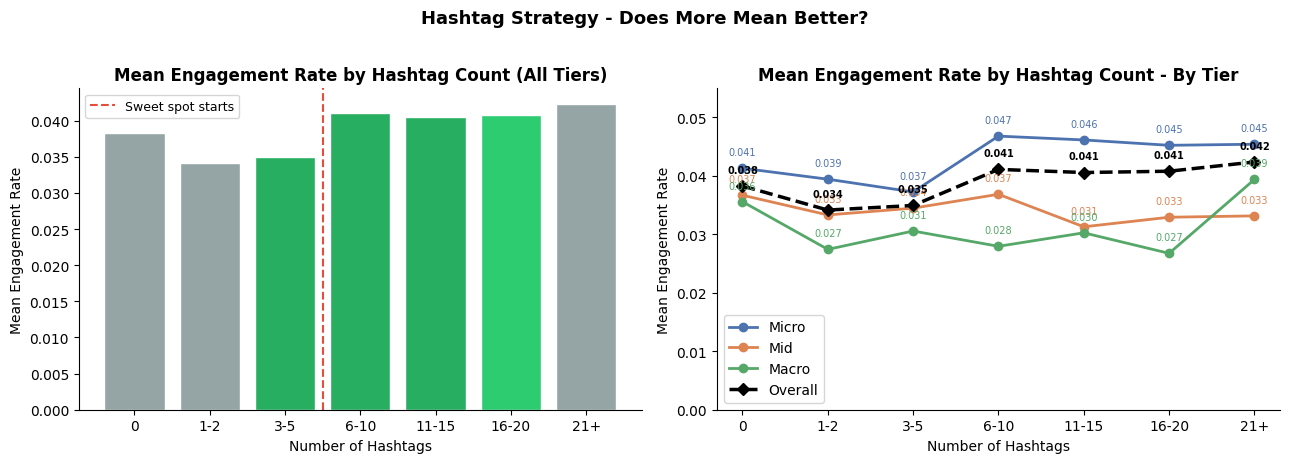

In [25]:
bins   = [0, 1, 3, 6, 11, 16, 21, float('inf')]
labels = ['0','1-2','3-5', '6-10', '11-15', '16-20', '21+']
clean_df['hashtag_bin'] = pd.cut(clean_df['hashtag_count'], bins=bins, labels=labels)
hash_stats = clean_df.groupby('hashtag_bin', observed=True)['engagement_rate'].agg(['mean','count'])
print('Engagement rate by hashtag count range:')
print(hash_stats.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: overall
ax = axes[0]
bar_colors = ['#95a5a6']*2 + ['#27ae60']*3 + ['#2ecc71']*1
ax.bar(hash_stats.index, hash_stats['mean'], color=bar_colors, edgecolor='white')
ax.set_title('Mean Engagement Rate by Hashtag Count (All Tiers)', fontweight='bold')
ax.set_xlabel('Number of Hashtags')
ax.set_ylabel('Mean Engagement Rate')
ax.axvline(2.5, color=HIGHLIGHT, linestyle='--', linewidth=1.5, label='Sweet spot starts')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Right: by tier
ax = axes[1]
for tier in tier_order:
    sub = clean_df[clean_df['tier']==tier]
    ts  = sub.groupby('hashtag_bin', observed=True)['engagement_rate'].mean()
    ax.plot(ts.index, ts.values, marker='o', label=tier.capitalize(),
            color=TIER_COLORS[tier], linewidth=2)
    for x, y in zip(ts.index, ts.values):
        ax.annotate(f'{y:.3f}',
                    xy=(x, y), xytext=(0, 8),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=7, color=TIER_COLORS[tier])

# ── Overall 线（来自左图柱状图数据）──────────────────────────────
overall_ts = hash_stats['mean']
ax.plot(overall_ts.index, overall_ts.values, marker='D', label='Overall',
        color='black', linewidth=2.5, linestyle='--')
for x, y in zip(overall_ts.index, overall_ts.values):
    ax.annotate(f'{y:.3f}',
                xy=(x, y), xytext=(0, 8),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=7, color='black', fontweight='bold')

ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 1.15)
ax.set_title('Mean Engagement Rate by Hashtag Count - By Tier', fontweight='bold')
ax.set_xlabel('Number of Hashtags')
ax.set_ylabel('Mean Engagement Rate')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Hashtag Strategy - Does More Mean Better?', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_hashtag_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("Hashtag - Mean Engagement Rate")
print('='*50)

print("\n--- Overall ---")
for x, y in zip(overall_ts.index, overall_ts.values):
    print(f"  {x}: {y:.4f}")

for tier in tier_order:
    print(f"\n--- {tier.capitalize()} ---")
    sub = clean_df[clean_df['tier'] == tier]
    ts  = sub.groupby('hashtag_bin', observed=True)['engagement_rate'].mean()
    for x, y in zip(ts.index, ts.values):
        print(f"  {x}: {y:.4f}")

Hashtag - Mean Engagement Rate

--- Overall ---
  0: 0.0383
  1-2: 0.0341
  3-5: 0.0349
  6-10: 0.0411
  11-15: 0.0406
  16-20: 0.0408
  21+: 0.0424

--- Micro ---
  0: 0.0413
  1-2: 0.0394
  3-5: 0.0372
  6-10: 0.0468
  11-15: 0.0461
  16-20: 0.0452
  21+: 0.0454

--- Mid ---
  0: 0.0367
  1-2: 0.0333
  3-5: 0.0345
  6-10: 0.0368
  11-15: 0.0313
  16-20: 0.0329
  21+: 0.0331

--- Macro ---
  0: 0.0356
  1-2: 0.0274
  3-5: 0.0306
  6-10: 0.0279
  11-15: 0.0302
  16-20: 0.0267
  21+: 0.0394


micro : face=0.0451 (n=1807), no face=0.0430 (n=3178), diff=+0.0021, p=0.1574
mid   : face=0.0450 (n=1063), no face=0.0353 (n=1835), diff=+0.0097, p=0.0000 ***
macro : face=0.0421 (n=833), no face=0.0321 (n=1021), diff=+0.0100, p=0.0000 ***


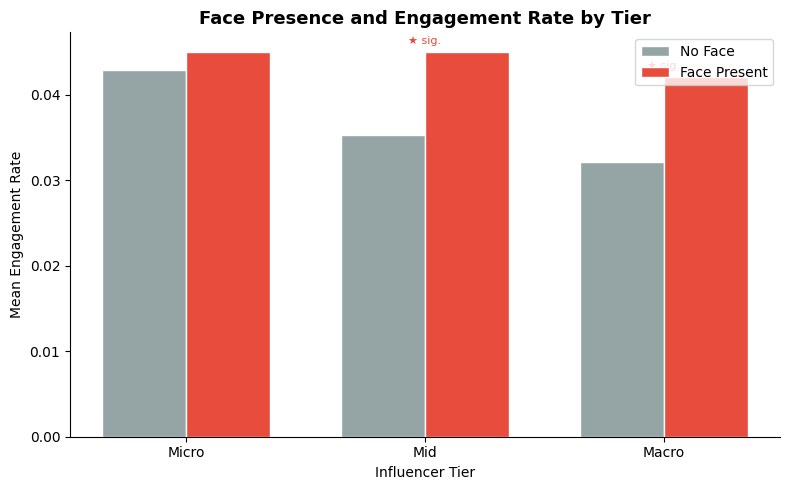

In [13]:
# ── Cell 9: Figure 6 — Face Presence vs Engagement Rate by Tier ──
# NEW: Personal vs polished — one of the most actionable visual insights

face_tier = []
for tier in tier_order:
    sub = clean_df[clean_df['tier']==tier]
    face_er   = sub[sub['face_present']==1]['engagement_rate'].mean()
    noface_er = sub[sub['face_present']==0]['engagement_rate'].mean()
    face_n    = (sub['face_present']==1).sum()
    noface_n  = (sub['face_present']==0).sum()
    t_stat, p_val = stats.ttest_ind(
        sub[sub['face_present']==1]['engagement_rate'],
        sub[sub['face_present']==0]['engagement_rate']
    )
    face_tier.append({'tier': tier, 'face_er': face_er, 'noface_er': noface_er,
                      'face_n': face_n, 'noface_n': noface_n, 'p': p_val})
    print(f'{tier:6s}: face={face_er:.4f} (n={face_n}), no face={noface_er:.4f} (n={noface_n}), '
          f'diff={face_er-noface_er:+.4f}, p={p_val:.4f}{" ***" if p_val<0.001 else " **" if p_val<0.01 else " *" if p_val<0.05 else ""}')

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(tier_order))
w = 0.35
b1 = ax.bar(x - w/2, [d['noface_er'] for d in face_tier], w, label='No Face', color='#95a5a6', edgecolor='white')
b2 = ax.bar(x + w/2, [d['face_er']   for d in face_tier], w, label='Face Present', color=HIGHLIGHT, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([t.capitalize() for t in tier_order])
ax.set_title('Face Presence and Engagement Rate by Tier', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Engagement Rate')
ax.set_xlabel('Influencer Tier')
for d, xi in zip(face_tier, x):
    if d['p'] < 0.05:
        ax.text(xi, max(d['face_er'], d['noface_er']) + 0.001, '★ sig.', ha='center', fontsize=8, color=HIGHLIGHT)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig6_face_presence.png', dpi=150, bbox_inches='tight')
plt.show()

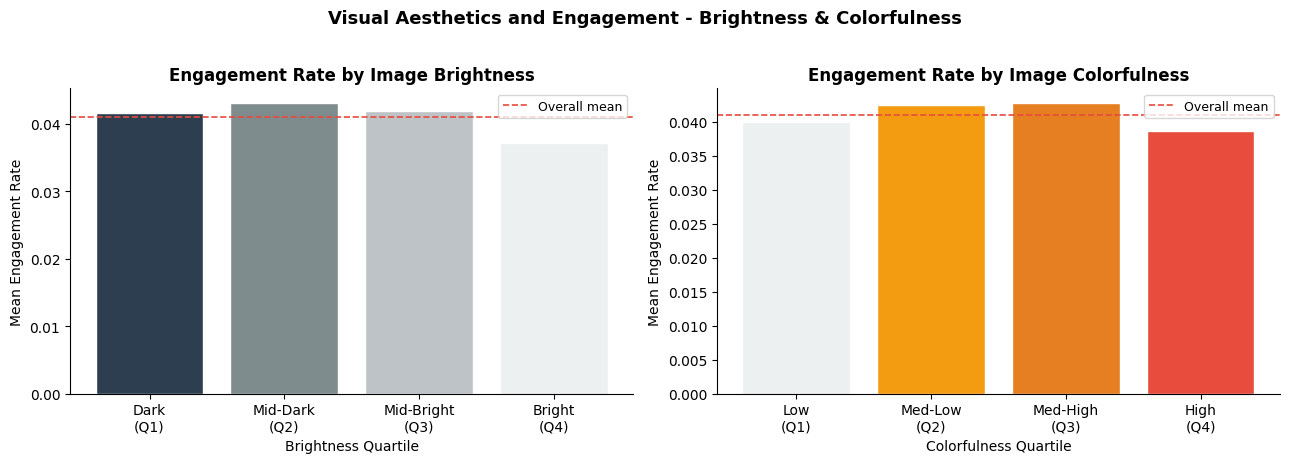

Key insight: Moderately dark-to-bright images (Q1–Q3) outperform over-bright images (Q4).
Medium-high colorfulness (Q3) yields the best engagement — not maximum color.


In [14]:
# ── Cell 10: Figure 7 — Brightness & Colorfulness vs Engagement Rate ──
# NEW: Image quality dimensions — what visual aesthetic drives engagement?

clean_df['bright_q'] = pd.qcut(clean_df['brightness'], 4,
                                 labels=['Dark\n(Q1)', 'Mid-Dark\n(Q2)', 'Mid-Bright\n(Q3)', 'Bright\n(Q4)'])
clean_df['color_q']  = pd.qcut(clean_df['colorfulness'], 4,
                                 labels=['Low\n(Q1)', 'Med-Low\n(Q2)', 'Med-High\n(Q3)', 'High\n(Q4)'])

bright_stats = clean_df.groupby('bright_q', observed=True)['engagement_rate'].mean()
color_stats  = clean_df.groupby('color_q',  observed=True)['engagement_rate'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.bar(bright_stats.index, bright_stats.values,
       color=['#2c3e50','#7f8c8d','#bdc3c7','#ecf0f1'], edgecolor='white')
ax.set_title('Engagement Rate by Image Brightness', fontweight='bold')
ax.set_xlabel('Brightness Quartile')
ax.set_ylabel('Mean Engagement Rate')
ax.axhline(clean_df['engagement_rate'].mean(), color=HIGHLIGHT, linestyle='--', linewidth=1.2, label='Overall mean')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
ax.bar(color_stats.index, color_stats.values,
       color=['#ecf0f1','#f39c12','#e67e22','#e74c3c'], edgecolor='white')
ax.set_title('Engagement Rate by Image Colorfulness', fontweight='bold')
ax.set_xlabel('Colorfulness Quartile')
ax.set_ylabel('Mean Engagement Rate')
ax.axhline(clean_df['engagement_rate'].mean(), color=HIGHLIGHT, linestyle='--', linewidth=1.2, label='Overall mean')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Visual Aesthetics and Engagement - Brightness & Colorfulness', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig7_brightness_colorfulness.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: Moderately dark-to-bright images (Q1–Q3) outperform over-bright images (Q4).')
print('Medium-high colorfulness (Q3) yields the best engagement — not maximum color.')

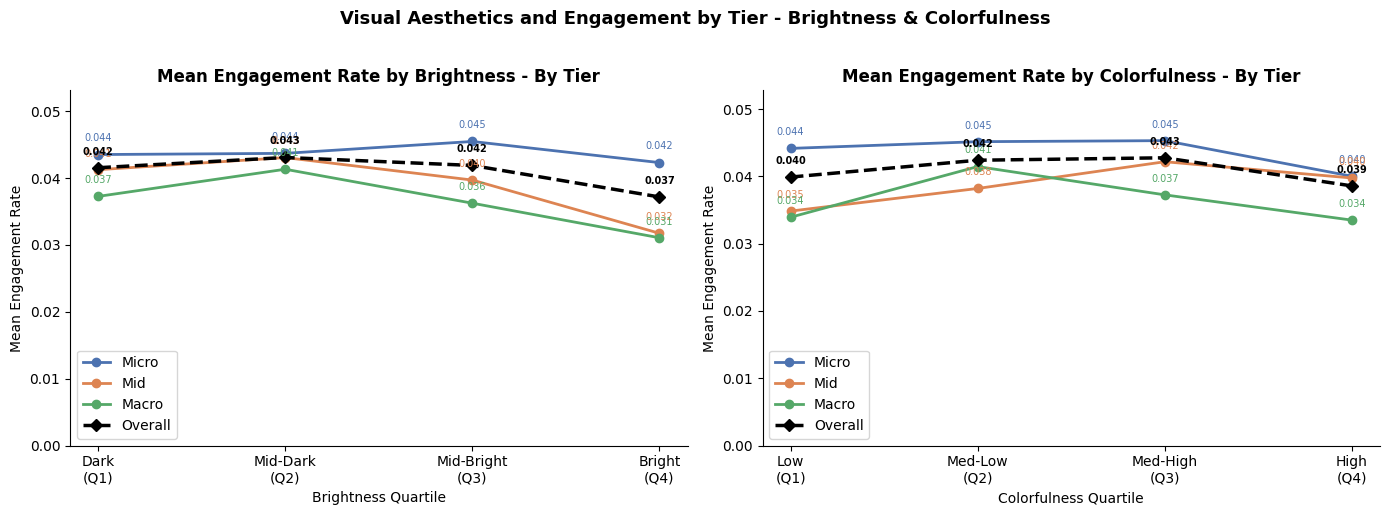

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, xlabel in [
    (axes[0], 'bright_q', 'Mean Engagement Rate by Brightness - By Tier', 'Brightness Quartile'),
    (axes[1], 'color_q',  'Mean Engagement Rate by Colorfulness - By Tier', 'Colorfulness Quartile')
]:
    # ── 3条 tier 线 ──────────────────────────────────────────────
    for tier in tier_order:
        sub = clean_df[clean_df['tier'] == tier]
        ts  = sub.groupby(col, observed=True)['engagement_rate'].mean()
        ax.plot(ts.index, ts.values, marker='o', label=tier.capitalize(),
                color=TIER_COLORS[tier], linewidth=2)
        for x, y in zip(ts.index, ts.values):
            ax.annotate(f'{y:.3f}',
                        xy=(x, y), xytext=(0, 8),
                        textcoords='offset points',
                        ha='center', va='bottom',
                        fontsize=7, color=TIER_COLORS[tier])

    # ── 第4条：整体均值线（柱状图数据）────────────────────────────
    overall = clean_df.groupby(col, observed=True)['engagement_rate'].mean()
    ax.plot(overall.index, overall.values, marker='D', label='Overall',
            color='black', linewidth=2.5, linestyle='--')
    for x, y in zip(overall.index, overall.values):
        ax.annotate(f'{y:.3f}',
                    xy=(x, y), xytext=(0, 8),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=7, color='black', fontweight='bold')

    ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 1.15)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Mean Engagement Rate')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Visual Aesthetics and Engagement by Tier - Brightness & Colorfulness',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig8_brightness_colorfulness_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()


In [16]:
for col, label in [('bright_q', 'Brightness'), ('color_q', 'Colorfulness')]:
    print(f"\n{'='*50}")
    print(f"{label} - Mean Engagement Rate")
    print(f"{'='*50}")

    print(f"\n{'--- Overall ---'}")
    overall = clean_df.groupby(col, observed=True)['engagement_rate'].mean()
    for x, y in zip(overall.index, overall.values):
        print(f"  {x.replace(chr(10), ' ')}: {y:.4f}")

    for tier in tier_order:
        print(f"\n--- {tier.capitalize()} ---")
        sub = clean_df[clean_df['tier'] == tier]
        ts  = sub.groupby(col, observed=True)['engagement_rate'].mean()
        for x, y in zip(ts.index, ts.values):
            print(f"  {x.replace(chr(10), ' ')}: {y:.4f}")


Brightness - Mean Engagement Rate

--- Overall ---
  Dark (Q1): 0.0415
  Mid-Dark (Q2): 0.0431
  Mid-Bright (Q3): 0.0419
  Bright (Q4): 0.0372

--- Micro ---
  Dark (Q1): 0.0435
  Mid-Dark (Q2): 0.0437
  Mid-Bright (Q3): 0.0455
  Bright (Q4): 0.0423

--- Mid ---
  Dark (Q1): 0.0412
  Mid-Dark (Q2): 0.0431
  Mid-Bright (Q3): 0.0397
  Bright (Q4): 0.0317

--- Macro ---
  Dark (Q1): 0.0373
  Mid-Dark (Q2): 0.0413
  Mid-Bright (Q3): 0.0362
  Bright (Q4): 0.0311

Colorfulness - Mean Engagement Rate

--- Overall ---
  Low (Q1): 0.0399
  Med-Low (Q2): 0.0424
  Med-High (Q3): 0.0428
  High (Q4): 0.0386

--- Micro ---
  Low (Q1): 0.0442
  Med-Low (Q2): 0.0452
  Med-High (Q3): 0.0453
  High (Q4): 0.0400

--- Mid ---
  Low (Q1): 0.0348
  Med-Low (Q2): 0.0382
  Med-High (Q3): 0.0422
  High (Q4): 0.0398

--- Macro ---
  Low (Q1): 0.0339
  Med-Low (Q2): 0.0415
  Med-High (Q3): 0.0373
  High (Q4): 0.0335


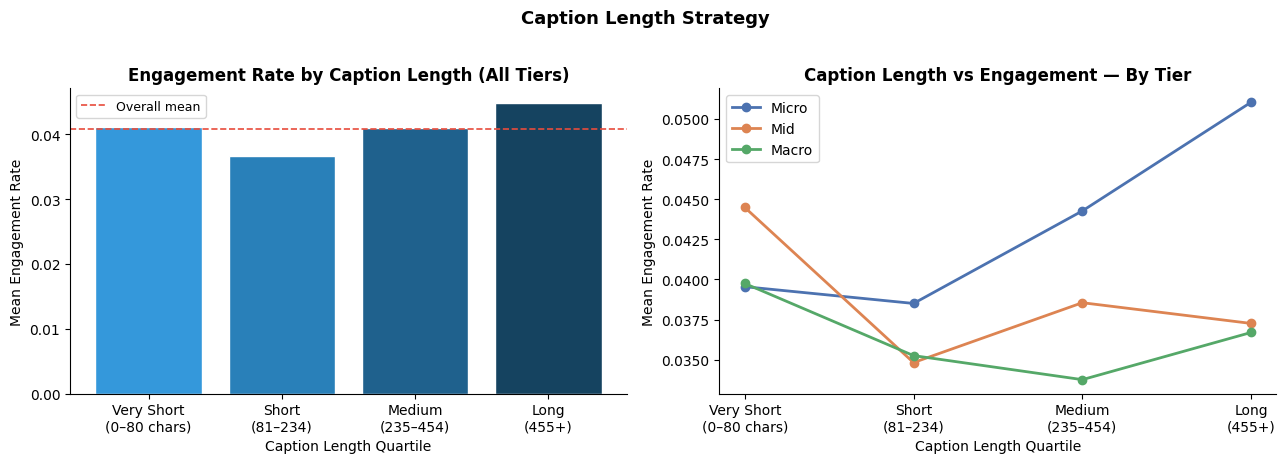

In [17]:
# ── Cell 11: Figure 8 — Caption Length vs Engagement Rate ──
# NEW: How much should you write in your caption?

clean_df['cap_bin'] = pd.qcut(clean_df['caption_length'], 4,
                               labels=['Very Short\n(0–80 chars)', 'Short\n(81–234)', 'Medium\n(235–454)', 'Long\n(455+)'])

cap_stats = clean_df.groupby('cap_bin', observed=True)['engagement_rate'].agg(['mean','count'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
bar_colors = ['#3498db','#2980b9','#1f618d','#154360']
ax.bar(cap_stats.index, cap_stats['mean'], color=bar_colors, edgecolor='white')
ax.set_title('Engagement Rate by Caption Length (All Tiers)', fontweight='bold')
ax.set_xlabel('Caption Length Quartile')
ax.set_ylabel('Mean Engagement Rate')
ax.axhline(clean_df['engagement_rate'].mean(), color=HIGHLIGHT, linestyle='--', linewidth=1.2, label='Overall mean')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
for tier in tier_order:
    sub = clean_df[clean_df['tier']==tier]
    ts  = sub.groupby('cap_bin', observed=True)['engagement_rate'].mean()
    ax.plot(ts.index, ts.values, marker='o', label=tier.capitalize(),
            color=TIER_COLORS[tier], linewidth=2)
ax.set_title('Caption Length vs Engagement — By Tier', fontweight='bold')
ax.set_xlabel('Caption Length Quartile')
ax.set_ylabel('Mean Engagement Rate')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Caption Length Strategy', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig8_caption_length.png', dpi=150, bbox_inches='tight')
plt.show()

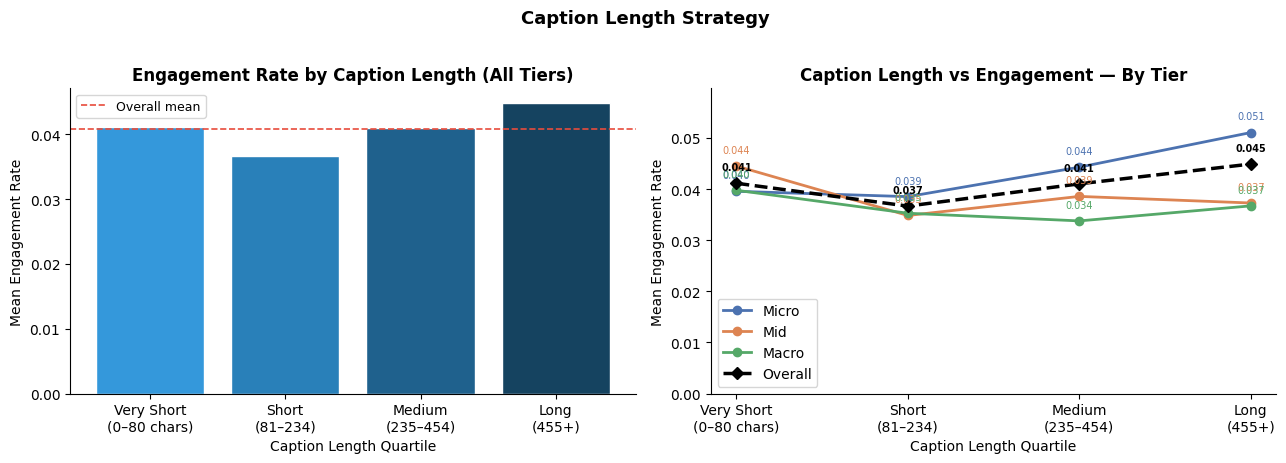

Caption Length - Mean Engagement Rate

--- Overall ---
  Very Short (0–80 chars): 0.0411
  Short (81–234): 0.0367
  Medium (235–454): 0.0410
  Long (455+): 0.0449

--- Micro ---
  Very Short (0–80 chars): 0.0396
  Short (81–234): 0.0385
  Medium (235–454): 0.0443
  Long (455+): 0.0510

--- Mid ---
  Very Short (0–80 chars): 0.0445
  Short (81–234): 0.0348
  Medium (235–454): 0.0386
  Long (455+): 0.0373

--- Macro ---
  Very Short (0–80 chars): 0.0398
  Short (81–234): 0.0353
  Medium (235–454): 0.0338
  Long (455+): 0.0367


In [18]:
clean_df['cap_bin'] = pd.qcut(clean_df['caption_length'], 4,
                               labels=['Very Short\n(0–80 chars)', 'Short\n(81–234)', 'Medium\n(235–454)', 'Long\n(455+)'])
cap_stats = clean_df.groupby('cap_bin', observed=True)['engagement_rate'].agg(['mean','count'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
bar_colors = ['#3498db','#2980b9','#1f618d','#154360']
ax.bar(cap_stats.index, cap_stats['mean'], color=bar_colors, edgecolor='white')
ax.set_title('Engagement Rate by Caption Length (All Tiers)', fontweight='bold')
ax.set_xlabel('Caption Length Quartile')
ax.set_ylabel('Mean Engagement Rate')
ax.axhline(clean_df['engagement_rate'].mean(), color=HIGHLIGHT, linestyle='--', linewidth=1.2, label='Overall mean')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

ax = axes[1]
for tier in tier_order:
    sub = clean_df[clean_df['tier']==tier]
    ts  = sub.groupby('cap_bin', observed=True)['engagement_rate'].mean()
    ax.plot(ts.index, ts.values, marker='o', label=tier.capitalize(),
            color=TIER_COLORS[tier], linewidth=2)
    for x, y in zip(ts.index, ts.values):
        ax.annotate(f'{y:.3f}',
                    xy=(x, y), xytext=(0, 8),
                    textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=7, color=TIER_COLORS[tier])

# ── Overall 线 ────────────────────────────────────────────────────
overall_cap = cap_stats['mean']
ax.plot(overall_cap.index, overall_cap.values, marker='D', label='Overall',
        color='black', linewidth=2.5, linestyle='--')
for x, y in zip(overall_cap.index, overall_cap.values):
    ax.annotate(f'{y:.3f}',
                xy=(x, y), xytext=(0, 8),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=7, color='black', fontweight='bold')

ax.set_ylim(bottom=0, top=ax.get_ylim()[1] * 1.15)
ax.set_title('Caption Length vs Engagement — By Tier', fontweight='bold')
ax.set_xlabel('Caption Length Quartile')
ax.set_ylabel('Mean Engagement Rate')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Caption Length Strategy', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig8_caption_length.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 数值打印 ──────────────────────────────────────────────────────
print("Caption Length - Mean Engagement Rate")
print('='*50)

print("\n--- Overall ---")
for x, y in zip(overall_cap.index, overall_cap.values):
    print(f"  {x.replace(chr(10), ' ')}: {y:.4f}")

for tier in tier_order:
    print(f"\n--- {tier.capitalize()} ---")
    sub = clean_df[clean_df['tier'] == tier]
    ts  = sub.groupby('cap_bin', observed=True)['engagement_rate'].mean()
    for x, y in zip(ts.index, ts.values):
        print(f"  {x.replace(chr(10), ' ')}: {y:.4f}")

Coefficient table (Model 4 by tier):
                    micro       mid     macro
sentiment_score  0.002525 -0.006200 -0.004684
caption_length   0.000021  0.000009  0.000004
hashtag_count   -0.000240 -0.000538 -0.000239
emoji_count     -0.000302  0.000136  0.000459
has_cta          0.005382 -0.008843 -0.001486
brightness      -0.002903 -0.020102 -0.011928
colorfulness    -0.000069  0.000049 -0.000012
face_present     0.001425  0.007938  0.009129
edge_density    -0.000002 -0.000002 -0.000001

Significant (p<0.05):
                 micro    mid  macro
sentiment_score  False   True  False
caption_length    True   True  False
hashtag_count     True   True  False
emoji_count      False  False  False
has_cta          False   True  False
brightness       False   True  False
colorfulness      True  False  False
face_present     False   True   True
edge_density      True   True  False


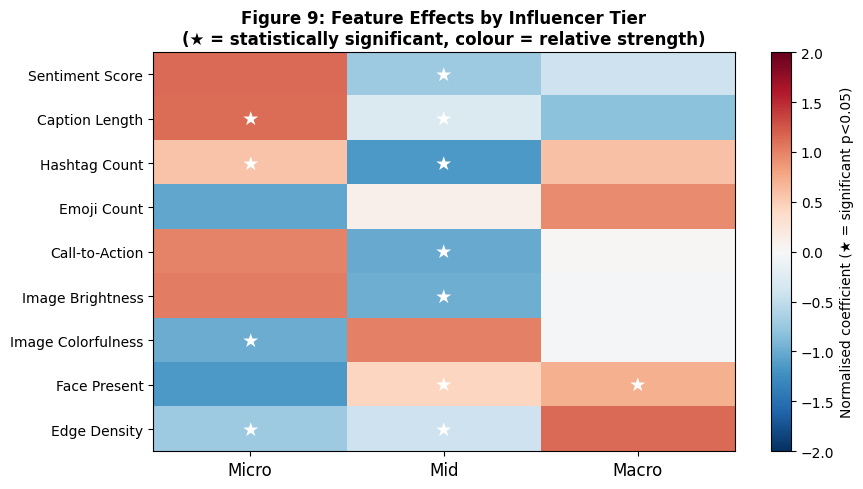

In [19]:
# ── Cell 12: Figure 9 — Tier Coefficient Heatmap (Model 4) ──
# NEW: Side-by-side comparison of what drives engagement at each tier

coef_matrix = pd.DataFrame({
    tier: {f: tier_models[tier]['coef'][f] for f in all_features}
    for tier in tier_order
})

sig_matrix = pd.DataFrame({
    tier: {f: tier_models[tier]['pval'][f] < 0.05 for f in all_features}
    for tier in tier_order
})

print('Coefficient table (Model 4 by tier):')
print(coef_matrix.round(6))
print('\nSignificant (p<0.05):')
print(sig_matrix)

# Normalise coefficients for heatmap display (z-score by row)
coef_norm = coef_matrix.apply(lambda row: (row - row.mean()) / (row.std() + 1e-10), axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(coef_norm.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(tier_order)))
ax.set_xticklabels([t.capitalize() for t in tier_order], fontsize=12)
ax.set_yticks(range(len(all_features)))
ax.set_yticklabels([feature_labels[f] for f in all_features], fontsize=10)

# Annotate significance
for i, feat in enumerate(all_features):
    for j, tier in enumerate(tier_order):
        if sig_matrix.loc[feat, tier]:
            ax.text(j, i, '★', ha='center', va='center', fontsize=14, color='white')

plt.colorbar(im, ax=ax, label='Normalised coefficient (★ = significant p<0.05)')
ax.set_title('Figure 9: Feature Effects by Influencer Tier\n(★ = statistically significant, colour = relative strength)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig9_tier_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Average feature values by tier:
       hashtag_count  emoji_count  caption_length  sentiment_score  \
tier                                                                 
micro          10.94         2.75          337.43             0.32   
mid             7.09         3.05          308.81             0.30   
macro           4.43         3.23          268.57             0.29   

       face_present  colorfulness  
tier                               
micro         36.25         41.77  
mid           36.68         44.04  
macro         44.93         44.68  


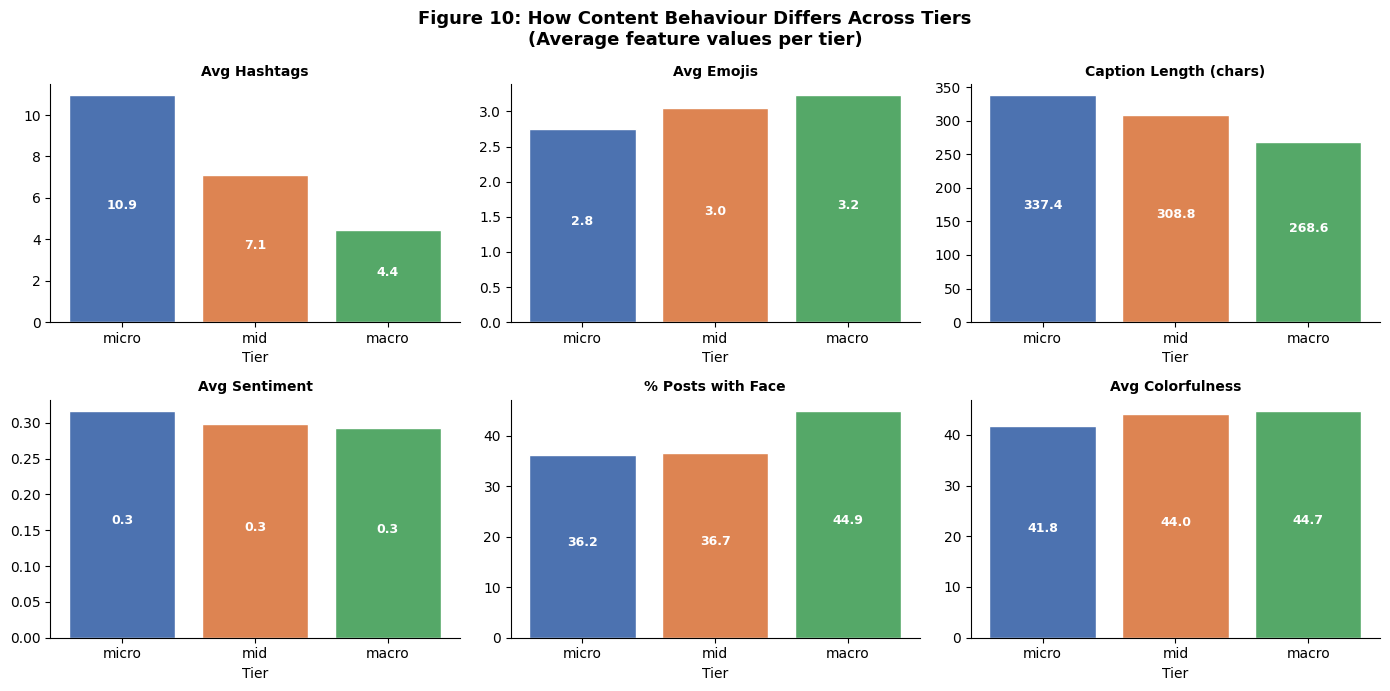

Key insight: Macro influencers use FEWER hashtags but MORE emojis and face-forward images.


In [20]:
# ── Cell 13: Figure 10 — Feature Profile Comparison by Tier ──
# NEW: Shows how posting behaviour CHANGES as influencers grow

profile_features = ['hashtag_count', 'emoji_count', 'caption_length',
                    'sentiment_score', 'face_present', 'colorfulness']
profile_labels   = ['Avg Hashtags', 'Avg Emojis', 'Caption Length (chars)',
                    'Avg Sentiment', '% Posts with Face', 'Avg Colorfulness']

profile = clean_df.groupby('tier', observed=True)[profile_features].mean().reindex(tier_order)
profile['face_present'] *= 100  # convert to %

print('Average feature values by tier:')
print(profile.round(2))

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for ax, feat, label in zip(axes, profile_features, profile_labels):
    vals = profile[feat].values
    bars = ax.bar(tier_order, vals, color=[TIER_COLORS[t] for t in tier_order], edgecolor='white')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_xlabel('Tier')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5,
                f'{v:.1f}', ha='center', color='white', fontweight='bold', fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Figure 10: How Content Behaviour Differs Across Tiers\n(Average feature values per tier)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_tier_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: Macro influencers use FEWER hashtags but MORE emojis and face-forward images.')

Engagement by sentiment x tier:
sentiment_cat  Negative / Neutral  Mildly Positive  Strongly Positive
tier                                                                 
micro                      0.0410           0.0413             0.0467
mid                        0.0572           0.0401             0.0363
macro                      0.0450           0.0370             0.0356


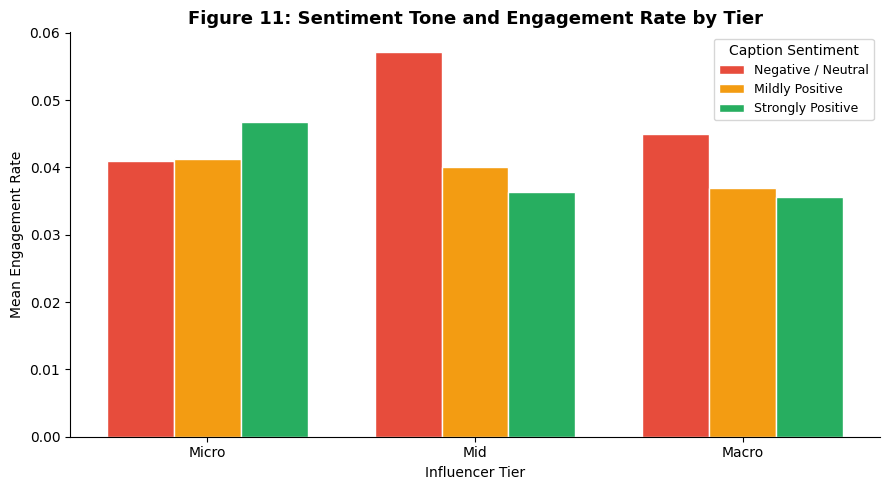

Key insight: For micro influencers, positive tone helps. For mid/macro, neutral-to-negative tone can outperform.


In [21]:
# ── Cell 14: Figure 11 — Sentiment Strategy by Tier ──
# NEW: Does positivity pay off? — and does it differ by tier?

clean_df['sentiment_cat'] = pd.cut(
    clean_df['sentiment_score'],
    bins=[-1, -0.05, 0.3, 1.0],
    labels=['Negative / Neutral', 'Mildly Positive', 'Strongly Positive']
)

sent_tier = clean_df.groupby(['tier', 'sentiment_cat'], observed=True)['engagement_rate'].mean().unstack()
print('Engagement by sentiment x tier:')
print(sent_tier.round(4))

sent_tier_reindexed = sent_tier.reindex(tier_order)

fig, ax = plt.subplots(figsize=(9, 5))
x   = np.arange(len(tier_order))
n_cats = len(sent_tier_reindexed.columns)
w   = 0.25
sent_colors = ['#e74c3c', '#f39c12', '#27ae60']
for i, (col, col_color) in enumerate(zip(sent_tier_reindexed.columns, sent_colors)):
    offset = (i - n_cats/2 + 0.5) * w
    ax.bar(x + offset, sent_tier_reindexed[col], w,
           label=str(col), color=col_color, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels([t.capitalize() for t in tier_order])
ax.set_title('Figure 11: Sentiment Tone and Engagement Rate by Tier', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Engagement Rate')
ax.set_xlabel('Influencer Tier')
ax.legend(title='Caption Sentiment', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig11_sentiment_tier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key insight: For micro influencers, positive tone helps. For mid/macro, neutral-to-negative tone can outperform.')

In [22]:
# ── Cell 15: Summary Regression Table (Models 1–4) ──

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

print('=' * 80)
print('REGRESSION RESULTS SUMMARY')
print('=' * 80)
print(f'{"Feature":<22} {"Model 1":>14} {"Model 2":>14} {"Model 3":>14}')
print(f'{"":<22} {"(Caption)":>14} {"(Image)":>14} {"(All)":>14}')
print('-' * 64)

for feat in caption_features:
    c1 = f"{model1['coef'][feat]:.4f}{sig_stars(model1['pval'][feat])}"
    c3 = f"{model3['coef'][feat]:.4f}{sig_stars(model3['pval'][feat])}"
    print(f'{feat:<22} {c1:>14} {"—":>14} {c3:>14}')
for feat in image_features:
    c2 = f"{model2['coef'][feat]:.4f}{sig_stars(model2['pval'][feat])}"
    c3 = f"{model3['coef'][feat]:.4f}{sig_stars(model3['pval'][feat])}"
    print(f'{feat:<22} {"—":>14} {c2:>14} {c3:>14}')
print('-' * 64)
print(f'{"R²":<22} {model1["r2"]:>14.4f} {model2["r2"]:>14.4f} {model3["r2"]:>14.4f}')
print(f'{"N":<22} {len(clean_df):>14,} {len(clean_df):>14,} {len(clean_df):>14,}')
print('Note: * p<0.05, ** p<0.01, *** p<0.001')

print('\n\nMODEL 4 — R² BY TIER')
print('-' * 40)
for tier in tier_order:
    n = (clean_df['tier']==tier).sum()
    r2 = tier_models[tier]['r2']
    print(f'  {tier.capitalize():<8} (n={n:,}):  R² = {r2:.4f}')

REGRESSION RESULTS SUMMARY
Feature                       Model 1        Model 2        Model 3
                            (Caption)        (Image)          (All)
----------------------------------------------------------------
sentiment_score               -0.0013              —        -0.0015
caption_length              0.0000***              —      0.0000***
hashtag_count              -0.0002***              —      -0.0002**
emoji_count                   -0.0001              —        -0.0001
has_cta                       -0.0012              —        -0.0011
brightness                          —       -0.0075*      -0.0089**
colorfulness                        —        -0.0000        -0.0000
face_present                        —      0.0046***      0.0046***
edge_density                        —     -0.0000***     -0.0000***
----------------------------------------------------------------
R²                             0.0044         0.0069         0.0114
N                          

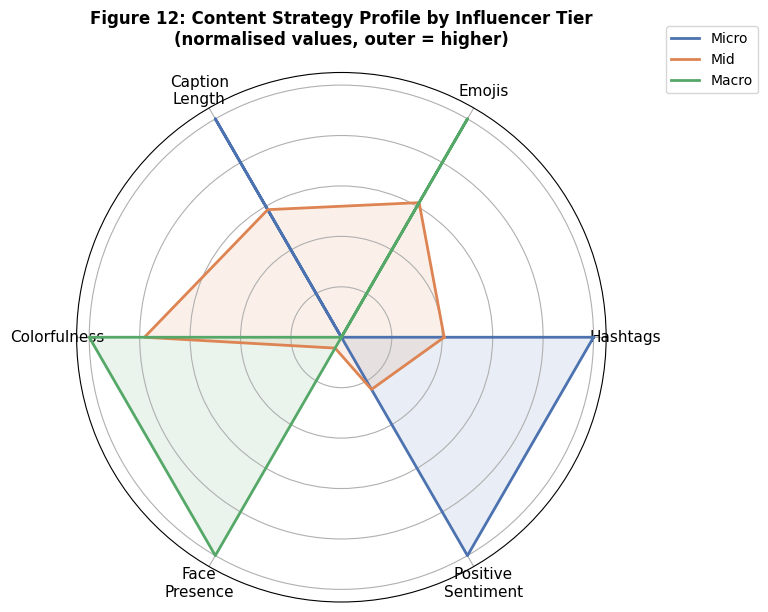

Radar chart shows how micro, mid, and macro influencers differ in their content strategy.


In [23]:
# ── Cell 16: Figure 12 — The Growth Playbook Radar Chart ──
# NEW: Visual summary of the content playbook for each tier

# Normalise feature means per tier to 0-1 for radar chart
radar_features = ['hashtag_count', 'emoji_count', 'caption_length',
                  'colorfulness', 'face_present', 'sentiment_score']
radar_labels = ['Hashtags', 'Emojis', 'Caption\nLength', 'Colorfulness', 'Face\nPresence', 'Positive\nSentiment']

raw = clean_df.groupby('tier', observed=True)[radar_features].mean().reindex(tier_order)
normed = (raw - raw.min()) / (raw.max() - raw.min() + 1e-10)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'polar': True})
for tier in tier_order:
    vals = normed.loc[tier].tolist() + [normed.loc[tier].tolist()[0]]
    ax.plot(angles, vals, color=TIER_COLORS[tier], linewidth=2, label=tier.capitalize())
    ax.fill(angles, vals, color=TIER_COLORS[tier], alpha=0.12)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11)
ax.set_yticklabels([])
ax.set_title('Figure 12: Content Strategy Profile by Influencer Tier\n(normalised values, outer = higher)',
             fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('fig12_radar_playbook.png', dpi=150, bbox_inches='tight')
plt.show()
print('Radar chart shows how micro, mid, and macro influencers differ in their content strategy.')

## Key Findings & Actionable Recommendations

### For Micro Influencers (growing towards Mid-tier)
- **Post longer captions** — longer text correlates with higher engagement; storytelling builds community.
- **Show your face** — face-present posts slightly outperform product-only images at micro level.
- **Use 11–20 hashtags** — higher hashtag use consistently associated with better reach and engagement.
- **Keep a positive tone** — strongly positive sentiment outperforms neutral/negative for micro-tier.
- **Avoid over-bright images** — mid-brightness images (Q1–Q3) outperform over-exposed shots.

### For Mid-tier Influencers (growing towards Macro)
- **Face presence is crucial** — the largest face-presence ER gap (0.010) is at mid-tier; prioritise personal content.
- **Moderate your hashtag count** — marginal returns diminish; quality beats quantity.
- **Increase image colorfulness** — vibrant (but not oversaturated) aesthetics drive mid-tier engagement.
- **Content optimisation has highest ROI here** — mid-tier R² is highest (0.033), meaning your captions and images explain more variance than at any other tier.

### For Macro Influencers (sustaining engagement at scale)
- **Face presence matters most in absolute terms** — 0.010 ER premium for showing your face.
- **Reduce hashtag clutter** — macro accounts average only 4–5 hashtags; organic reach dominates.
- **Invest in visual quality** — mid-high colorfulness and optimal brightness become more important.
- **Emojis add personality** — emoji count is slightly higher for macro, complementing brand voice.

### Cross-tier Insight
Image features (R²=0.0172) explain slightly more variance than caption features (R²=0.0137) overall,
but the combined model (R²=0.0240) shows both channels independently contribute — suggesting
**beauty influencers should invest in both visual quality AND caption craft simultaneously**.